In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt

from src.analysis import run_two_way_sensitivity_analysis
from src.config import variable_names
from src.core import Variable
from src.models import NetIncomeModel, MarketPriceModel
from src.variables import Cost, PriceToEarningsRatio
from src.visualization import generate_heatmap_from_df

In [2]:
variables = {
    variable_names.REVENUE: Variable(min=80000.0, exp=100000.0, max=120000.0),
    variable_names.COST: Cost(min=30000.0, exp=40000.0, max=50000.0),
    variable_names.PE_RATIO: PriceToEarningsRatio(min=5.0, exp=8.0, max=10.0)
}

pipeline = [NetIncomeModel(), MarketPriceModel()]

In [3]:
two_way_sensitivity_analysis_report = run_two_way_sensitivity_analysis(
    variables=variables,
    param_x_name=variable_names.REVENUE,
    param_y_name=variable_names.COST,
    model_pipeline=pipeline,
    target_output_name=variable_names.MARKET_PRICE,
    x_steps=20,
    y_steps=20
)

In [4]:
# print(two_way_sensitivity_analysis_report)

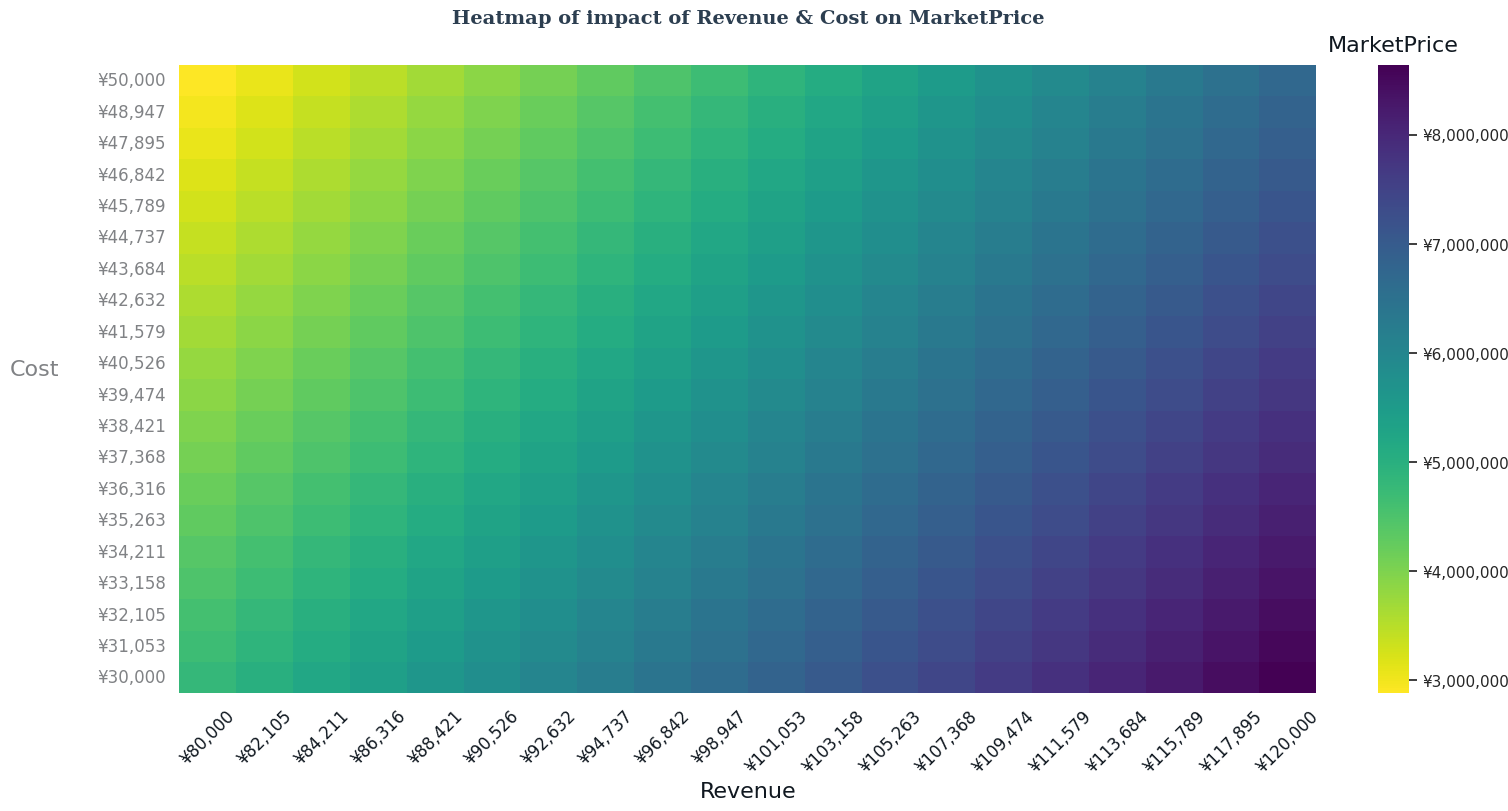

In [5]:
figure = generate_heatmap_from_df(two_way_sensitivity_analysis_report, variable_names.MARKET_PRICE)
plt.show()

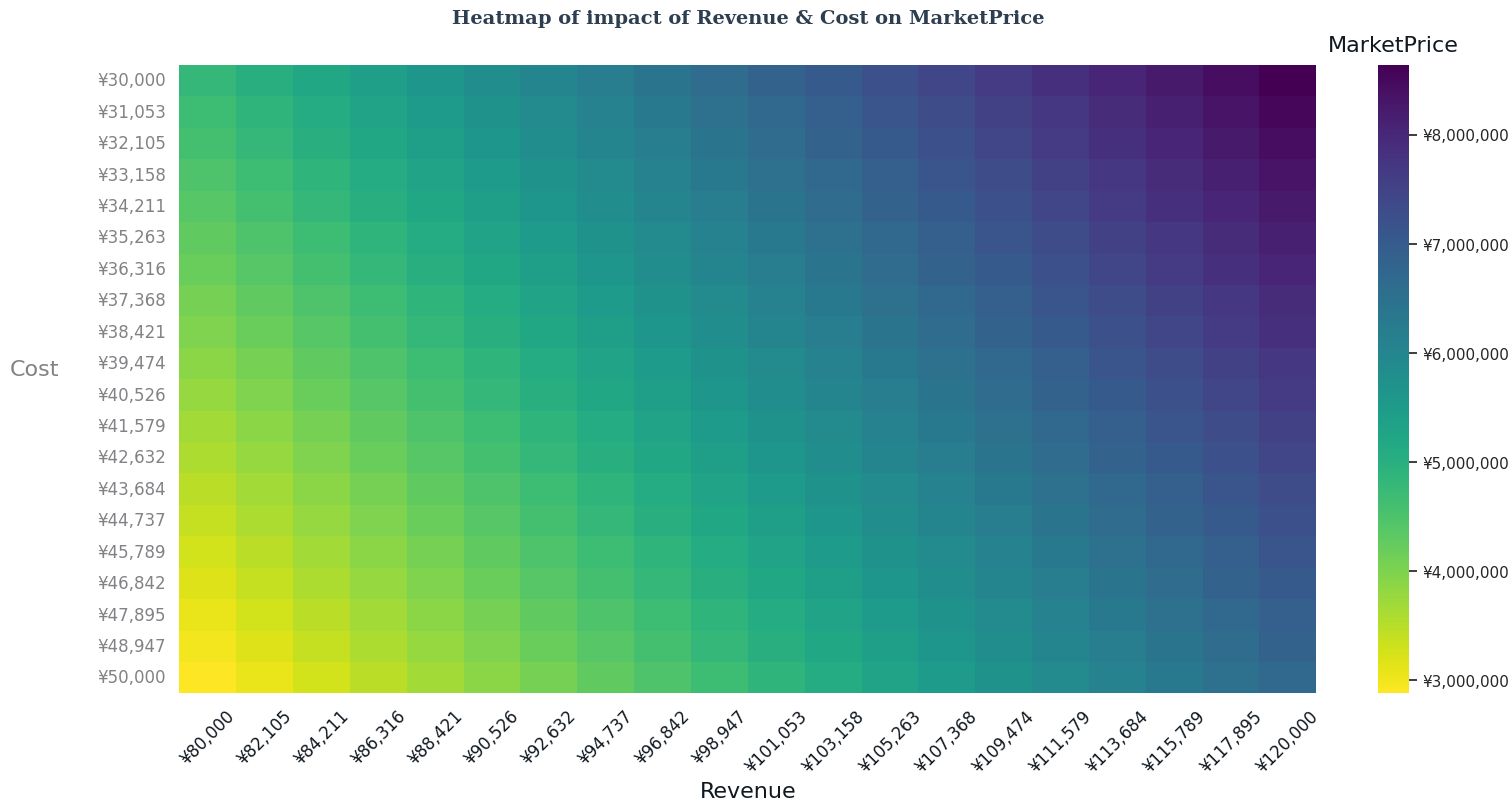

In [6]:
two_way_sensitivity_analysis_cost_decreasing_report = run_two_way_sensitivity_analysis(
    variables=variables,
    param_x_name=variable_names.REVENUE,
    param_y_name=variable_names.COST,
    model_pipeline=pipeline,
    target_output_name=variable_names.MARKET_PRICE,
    reverse_y=False,
    x_steps=20,
    y_steps=20
)

figure = generate_heatmap_from_df(two_way_sensitivity_analysis_cost_decreasing_report, variable_names.MARKET_PRICE)
plt.show()

In [7]:
plt.close()